# 1 Predicting Hospital Readmission for Diabetic Patients

A capstone end-to-end machine-learning pipeline for the [Diabetes 130-US Hospitals 1999–2008 dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008). The pipeline progresses from raw CSV to a deployable model artifact across eight notebooks (`01_overview` through `08_conclusion`), with every decision documented and every transformation validated.

**What this notebook delivers.** A complete framing of the problem before any code runs. By the end of section 1.12, the reader should know the clinical motivation, the dataset's limitations, the modeling decisions the pipeline has already locked in, and the evaluation criteria by which the final model will be judged.

**Why a written framing matters.** A model card written before the model is built forces honesty about constraints. It is much easier to acknowledge the cohort's vintage limitations or the class-imbalance penalty up front than to discover them halfway through hyperparameter tuning and have to justify post-hoc.


## 1.1 Clinical Background and Economic Motivation

**What we are establishing.** Why hospital readmission prediction is a non-trivial problem worth solving, and what stake hospitals have in getting it right.

**Why readmissions are a quality-and-cost lever.** Hospital readmissions within 30 days of discharge are a leading quality and cost problem in US healthcare. The Centers for Medicare & Medicaid Services penalizes hospitals with excess readmission rates under the [Hospital Readmissions Reduction Program (CMS HRRP)](https://www.cms.gov/medicare/payment/prospective-payment-systems/acute-inpatient-pps/hospital-readmissions-reduction-program-hrrp), and each preventable readmission represents a failure in care coordination, discharge planning, or post-discharge follow-up.

**Why diabetic patients in particular.** Diabetes is one of the most common chronic conditions among hospitalised adults, and the complexity of managing blood glucose, multiple medications, and frequent comorbidities makes this cohort high-risk for early bounce-back. A model that can flag patients at elevated readmission risk before they leave the building lets the care team intervene through closer follow-up scheduling, medication-regimen adjustment, home-health arrangements, or extended discharge education.

**The framing this notebook commits to.** This pipeline treats readmission risk as a *decision-support* signal, not an autonomous decision. The downstream evaluation (notebook 8) is structured around the operational question "how many real readmissions does the top-K% of model-flagged patients capture?", because that is the question a program manager actually buys a model to answer.


## 1.2 The Specific Question and Pipeline Scope

**What we are pinning down.** The exact prediction question, the data envelope, and the eight-notebook structure that takes raw CSV to deployable artefact.

**The prediction question.** Will a diabetic inpatient be readmitted within 30 days of discharge, using only information available at the moment of discharge?

**The eight-notebook pipeline.** Each stage saves its outputs to `../data/` and the next stage reads them back, so any single notebook can be re-run from disk without redoing earlier work.

1. **Cleaning** (notebook 2) removes clinically invalid records (deceased and hospice patients, unknown gender) and drops zero-information columns.
2. **Exploration** (notebook 3) surfaces class imbalance, missingness patterns, and which features carry univariate, bivariate, and multivariate signal.
3. **Feature engineering** (notebook 4) maps ICD-9 codes to clinical chapters, converts age brackets to numeric midpoints, encodes lab missingness as binary flags, aggregates medication columns, log-transforms prior-utilisation counts, and derives interaction features.
4. **Preprocessing** (notebook 5) performs a patient-grouped 70/10/20 train/val/test split, one-hot encoding, standard scaling, and mutual-information feature selection.
5. **Hyperparameter optimisation** (notebook 6) runs Ray-distributed randomised search over five model families (Logistic Regression, Random Forest, XGBoost, CatBoost, MLP) using patient-grouped cross-validation. The best configuration per family is persisted to `data/tuned_results.joblib` for downstream consumption.
6. **Model training** (notebook 7) refits each family at its best tuned configuration on the full training partition, runs the threshold sweep, overfitting check, confusion matrices, ROC/PR curves, and feature-importance review, and writes the fitted models alongside their validation metrics.
7. **Selection and final evaluation** (notebook 8) aggregates every result into a leaderboard, picks a champion, and runs the held-out test set through a comprehensive diagnostic suite, then writes the deployable bundle.

**Why eight rather than one mega-notebook.** Stage isolation is the cheapest defence against look-ahead bias. When the test-set evaluation lives in its own notebook that has never imported the training code, it is structurally harder to leak test information into model selection. The HPO-before-training ordering (notebook 6 before notebook 7) keeps that defence intact: tuning is done with patient-grouped cross-validated scores on the training partition only, and the validation and test sets stay untouched until notebooks 7 and 8 respectively.


## 1.3 The Dataset at a Glance

**What we are computing.** A quick, executable summary of the raw dataset. The numbers cited throughout the rest of this notebook (row counts, patient counts, prevalence) are sourced from this cell so that the prose stays honest if the file ever changes.

**Why an executable preview belongs in the overview.** Two of the modelling decisions made later in the pipeline (the patient-level split in notebook 5 and the imbalance-aware metric choice in notebook 6) are direct consequences of two numbers visible only when you load the file: the encounter-to-patient ratio and the positive-class prevalence. Showing those numbers here means the reader can connect each decision to the data feature that motivated it.


Raw dataset shape       : (101766, 50)
Unique patients         : 71,518
Encounters per patient  : mean=1.42, median=1, max=40
Repeated patients       : 16,773 (23.5% of patients, 47,021 encounters)

Target distribution (raw):
    NO:  54,864  (53.9%)
   >30:  35,545  (34.9%)
   <30:  11,357  (11.2%)

Positive-class prevalence (<30 days): 11.160%


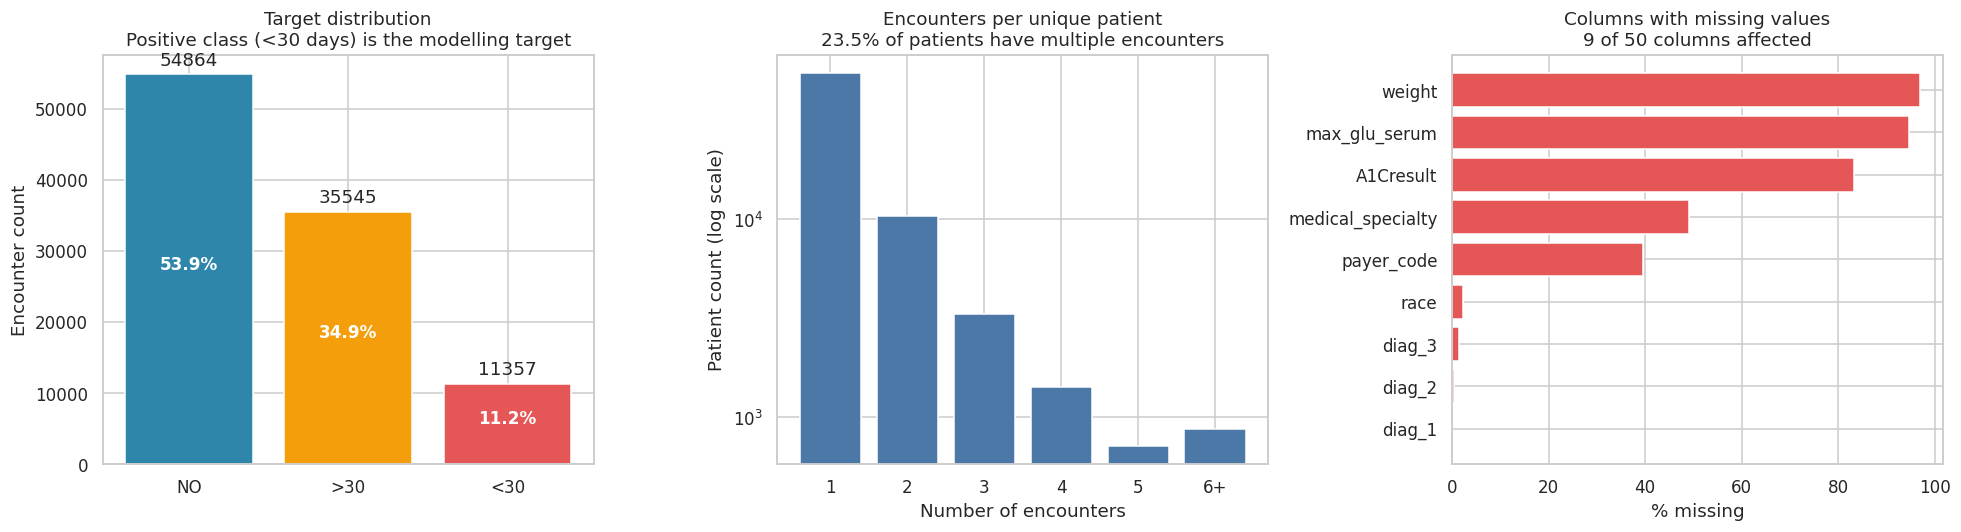

In [1]:
import sys
from pathlib import Path

# Resolve the project root via a marker walk so this notebook runs cleanly
# regardless of the working directory (Jupyter UI, papermill, or 'python -m'
# launched from elsewhere all hit the same ROOT). The shared
# 'resolve_raw_csv()' helper then honours '$MEDIWATCH_RAW_CSV', the local
# 'orig_dataset/' folder, and the sibling fallback in that order.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from helpers.mlops_helpers import resolve_raw_csv

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RAW_PATH = resolve_raw_csv("diabetic_data.csv")
df_raw = pd.read_csv(RAW_PATH, na_values="?", low_memory=False)

n_encounters = len(df_raw)
n_patients = df_raw["patient_nbr"].nunique()
n_features = df_raw.shape[1] - 2  # exclude encounter_id, patient_nbr

target_counts = df_raw["readmitted"].value_counts()
prevalence_30 = (df_raw["readmitted"] == "<30").mean()
encounters_per_patient = df_raw.groupby("patient_nbr").size()

print(f"Raw dataset shape       : {df_raw.shape}")
print(f"Unique patients         : {n_patients:,}")
print(f"Encounters per patient  : mean={encounters_per_patient.mean():.2f}, "
      f"median={encounters_per_patient.median():.0f}, max={encounters_per_patient.max()}")
print(f"Repeated patients       : {(encounters_per_patient > 1).sum():,} "
      f"({(encounters_per_patient > 1).mean():.1%} of patients, "
      f"{(encounters_per_patient[encounters_per_patient > 1].sum()):,} encounters)")
print()
print("Target distribution (raw):")
for cls, n in target_counts.items():
    print(f"  {cls:>4s}: {n:>7,d}  ({n / n_encounters:.1%})")
print(f"\nPositive-class prevalence (<30 days): {prevalence_30:.3%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: target distribution
colors = {"NO": "#2E86AB", ">30": "#F59E0B", "<30": "#E45756"}
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=[colors[c] for c in target_counts.index], edgecolor="white")
axes[0].bar_label(bars, fmt="%d", padding=3)
axes[0].set_title("Target distribution\nPositive class (<30 days) is the modelling target")
axes[0].set_ylabel("Encounter count")
for i, (cls, val) in enumerate(target_counts.items()):
    axes[0].text(i, val * 0.5, f"{val / n_encounters:.1%}",
                 ha="center", color="white", fontweight="bold", fontsize=11)

# Panel 2: encounters per patient (clipped at 6 for legibility)
clip = 6
counts = encounters_per_patient.clip(upper=clip).value_counts().sort_index()
labels = [str(i) for i in counts.index[:-1]] + [f"{clip}+"]
axes[1].bar(labels, counts.values, color="#4C78A8", edgecolor="white")
axes[1].set_title(
    f"Encounters per unique patient\n{(encounters_per_patient > 1).mean():.1%} of patients have multiple encounters")
axes[1].set_xlabel("Number of encounters")
axes[1].set_ylabel("Patient count (log scale)")
axes[1].set_yscale("log")

# Panel 3: missingness preview
missing = df_raw.isna().sum() / len(df_raw) * 100
missing = missing[missing > 0].sort_values(ascending=True)
axes[2].barh(missing.index, missing.values, color="#E45756", edgecolor="white")
axes[2].set_title(f"Columns with missing values\n{len(missing)} of {df_raw.shape[1]} columns affected")
axes[2].set_xlabel("% missing")

plt.tight_layout()
plt.show()


**Three observations the panel makes concrete.**

* **The target is heavily skewed.** Roughly one encounter in nine results in a 30-day readmission. Accuracy is therefore meaningless as a headline metric (a trivial "never readmits" classifier scores about 89% accuracy). Notebooks 6 onwards rank models on F1, AUC-ROC, and AUC-PR rather than accuracy. Threshold-aware diagnostics are added in notebooks 7 (sweep) and 8 (sensitivity analysis).
* **A substantial fraction of patients appears more than once.** Those repeat patients account for far more encounters than their share of the patient population suggests. A naive row-level shuffle would route the same patient into both training and test, leaking patient-specific behaviour. Notebook 5 addresses this with a two-stage patient-stratified `train_test_split` over unique `patient_nbr`, and CV inside notebook 6 then uses `StratifiedGroupKFold` per fold.
* **Several columns are not fully populated.** Two of the highest-missingness columns (`max_glu_serum` and `A1Cresult`) carry *informative* missingness: the test was not ordered, which usually means the clinician was not concerned. Notebook 4 encodes those as "test ordered" binary flags rather than imputing a clinically meaningless filler.

## 1.4 Target Variable: From Three Classes to a Binary Problem

**What we are deciding.** How to reduce the raw three-class `readmitted` label to a usable training target.

**The raw label.**

| Class | Meaning                               | Approximate proportion (raw) |
|-------|---------------------------------------|------------------------------|
| `NO`  | Patient was not readmitted            | majority                     |
| `>30` | Patient was readmitted after 30 days  | secondary                    |
| `<30` | Patient was readmitted within 30 days | minority, the positive class |

**Why binary, not three-class.** Two reasons:

1. **The clinical question is binary.** The `<30` outcome is the one CMS HRRP penalises and the one a discharge-planning intervention can directly affect. A readmission at 60 days is a different problem driven by different factors.
2. **The class boundary is the hard part.** Separating `<30` from `NO` is the same modelling difficulty as separating `<30` from `NO + >30`, and the binary framing simplifies every downstream choice (loss function, threshold tuning, decision-curve analysis).

**What we lose.** The `>30` category collapses into the negative class. A patient who is readmitted on day 45 looks identical to a patient who is never readmitted, from the model's perspective. This is acceptable for the operational question but worth flagging in any clinical interpretation.

**Why the cost asymmetry shapes the loss.** A missed readmission (false negative) carries a higher cost than a false alarm. Notebook 7's threshold sweep, refined in notebook 8's sensitivity analysis, makes this trade-off explicit rather than hiding it behind the default 0.5 cutoff.


## 1.5 Dataset Provenance and Temporal Validity

**What we are documenting.** The source of the data, the feature groups it contains, and the time period it covers. Each of these has direct implications for how confidently the model can be deployed.

**Source.** [Diabetes 130-US Hospitals for Years 1999–2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008) (UCI Machine Learning Repository). The raw file (`../orig_dataset/diabetic_data.csv`, before any filtering) holds **101,766 inpatient encounters** across **130 US hospitals**, collected from 1999 through 2008. The encounters originate from approximately 71,500 unique patients (the live count is printed in the §1.3 cell above). Each row is one encounter, not one patient. The post-cleaning row count and prevalence are recomputed live in notebooks 2 and 3.

**Consent and re-identification posture.** The UCI release was prepared as a de-identified dataset under HIPAA Safe Harbor: direct identifiers (name, address, full date of birth, medical record number, exact admission and discharge dates) have been stripped, and `patient_nbr` is a synthetic surrogate key used only to link the encounters of one individual, not protected health information. Residual re-identification risk is not zero. The combination of age bracket, race, gender, payer code, and hospital-of-care can become singling-out on small enough subgroups, particularly for rare race × age × specialty cells. This pipeline treats the dataset as a *teaching cohort*: there is no live human subject, no consent for downstream contact, and no permitted linkage to any external record. Any non-public cohort assembled in a real deployment would need to pass the k-anonymity review named in the privacy-posture block of `helpers/lab_publish.py` before being written to a shared artefact, and would need fresh IRB or DPIA review for the actual data source.

**Feature groups.**

* **Demographics.** Age (10-year brackets), race, gender.
* **Encounter.** Length of stay, count of lab procedures, count of non-lab procedures, total medications, admission type, discharge disposition, admission source.
* **Prior utilisation.** Counts of inpatient, outpatient, and emergency visits in the year preceding the encounter.
* **Diagnoses.** Three ICD-9 codes per encounter (primary, secondary, tertiary), each with roughly 700 unique values.
* **Lab results.** Maximum glucose serum and A1C result. Both are heavily missing (see §1.6).
* **Medications.** Twenty-one individual diabetes-drug columns plus dosage-change flags and an overall `change` indicator.
* **Administrative.** Payer code, medical specialty.

**Temporal validity.** The cohort spans 1999 through 2008. Three things have changed materially since then and would need to be addressed before any contemporary clinical pilot:

* **ICD-9 to ICD-10 transition (October 2015 in the US).** Every diagnosis column in this dataset is ICD-9. The notebook-4 frequency-based mapper would need to be re-derived on ICD-10 prefixes. A simple one-pass crosswalk is not sufficient because many ICD-9 codes map to multiple ICD-10 codes and vice versa.
* **Diabetes therapy has evolved substantially.** GLP-1 agonists (semaglutide, tirzepatide), SGLT-2 inhibitors, and continuous glucose monitoring have reshaped inpatient diabetes management. Insulin alone is no longer the dominant signal it appears to be in this cohort.
* **CMS HRRP penalties were introduced in 2012.** Hospitals' discharge and follow-up patterns have shifted in response, so the discharge-disposition feature distribution and its readmission correlation are unlikely to transfer cleanly to a 2026 cohort.

**Statement of intent.** This bundle is a capstone or educational deliverable, not a clinical-decision system. Any contemporary deployment would require retraining on a recent (post-2015) cohort with ICD-10 diagnoses, current medication lists, and CMS-era discharge patterns.

## 1.6 Key Modelling Challenges

**What we are surfacing.** Five properties of this dataset that make the prediction task hard. Each one motivates a specific decision later in the pipeline.

**Why state them up front.** A reader who understands these constraints will read the downstream notebooks as a sequence of *responses* to specific data realities rather than as a sequence of arbitrary choices.

1. **Severe class imbalance.** The `<30` class is the minority and the negative class dominates by roughly nine to one. We address this with class weighting (`class_weight="balanced"` for scikit-learn models, `scale_pos_weight` for boosted trees) rather than synthetic oversampling. SMOTE on encounter data risks duplicating leaked information across folds, so class weights are the safer, simpler tool that does not interact with the patient-level split.

2. **Weak individual predictors.** No single feature strongly separates the classes. Every univariate point-biserial correlation with the target sits well below 0.2, with `number_inpatient` topping the list at a still-modest value (notebook 3 section 3.6.5 reports the live numbers). Predictive power comes from feature combinations and interactions, which is why tree ensembles outperform the linear baseline once notebook 6's tuned configurations are refit in notebook 7 and ranked on the leaderboard in notebook 8.

3. **Repeated patients.** A substantial share of patients appears more than once in the data (live count printed in §1.3). That repeating subgroup accounts for an even larger share of all encounters, so a naive row-level split would leak the same patient across train and test. Notebook 5 performs the train/val/test holdout at the patient level via a two-stage stratified `train_test_split` over unique `patient_nbr`, so no patient appears in two splits, and the model is never evaluated on a patient it was trained on. Notebook 6's hyperparameter search then runs `StratifiedGroupKFold` inside each trial's cross-validation, preserving the same patient-grouping discipline across folds.

4. **Informative missingness in lab features.** The two heaviest-missingness columns (`max_glu_serum` and `A1Cresult`) are absent from the vast majority of rows. The missingness is *informative*: the test was not ordered, which usually means the clinician was not concerned. Notebook 4 encodes this as a "test ordered" binary flag rather than imputing a clinically meaningless filler value.

5. **High cardinality in diagnosis and specialty fields.** Each diagnosis column carries roughly 700 distinct ICD-9 codes, and `medical_specialty` has dozens of distinct values. Notebook 4 groups these into clinical and functional categories before encoding, so the one-hot matrix stays tractable and the model learns clinically interpretable buckets rather than noise.

**The thread that ties these together.** Every one of the five points above represents a *structural* property of the data that no amount of hyperparameter tuning can fix. The pipeline addresses them at the right stage (split, encode, transform, evaluate) so that they are dealt with once and never re-litigated downstream.

## 1.7 Pipeline at a Glance

**What we are presenting.** A diagrammatic view of how data flows through the eight notebooks, what each stage consumes, and what artefacts each stage writes.

**Why a diagram earns its space.** The dependencies between stages are not obvious from the file list alone. Most notably, hyperparameter search runs *before* the final training stage (notebook 6 produces the configurations that notebook 7 fits with), and the held-out test set is only ever loaded inside notebook 8. The diagram makes the linear consume/produce chain inspectable at a glance, which is exactly the architectural map to read before the code.


<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 900 1040" width="100%" role="img" aria-label="Diabetes-130 readmission pipeline diagram" style="max-width:900px;display:block;margin:0 auto;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif">
  <defs>
    <marker id="pl-arrow" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M0,0 L10,5 L0,10 z" fill="#64748b"/>
    </marker>
    <style>
      .pl-stage { fill:#1e3a5f; stroke:#0f2746; stroke-width:1 }
      .pl-badge { fill:#f59e0b }
      .pl-badge-txt { fill:#1f2937; font-weight:700; font-size:13.5px; text-anchor:middle; dominant-baseline:central }
      .pl-title { fill:#ffffff; font-weight:600; font-size:15px }
      .pl-sub { fill:#9fb8d4; font-size:11.5px }
      .pl-pill { fill:#2d4d75 }
      .pl-pill-txt { fill:#cfe1f7; font-size:11px; font-family:ui-monospace,'SF Mono',Menlo,Consolas,monospace }
      .pl-conn { stroke:#64748b; stroke-width:1.8; fill:none }
      .pl-raw { fill:#f1f5f9; stroke:#cbd5e1; stroke-width:1 }
      .pl-raw-txt { fill:#334155; font-size:12.5px; font-weight:500; font-family:ui-monospace,Menlo,monospace; text-anchor:middle; dominant-baseline:central }
    </style>
  </defs>

  <rect width="900" height="1040" fill="#ffffff"/>

  <!-- raw input -->
  <rect class="pl-raw" x="265" y="22" width="370" height="36" rx="8"/>
  <text class="pl-raw-txt" x="450" y="40">orig_dataset/diabetic_data.csv  ·  raw UCI input</text>
  <line class="pl-conn" x1="450" y1="60" x2="450" y2="76" marker-end="url(#pl-arrow)"/>

  <!-- §2 Data Cleaning -->
  <rect class="pl-stage" x="30" y="78" width="840" height="76" rx="10"/>
  <circle class="pl-badge" cx="62" cy="116" r="18"/>
  <text class="pl-badge-txt" x="62" y="116">2</text>
  <text class="pl-title" x="98" y="106">Data Cleaning</text>
  <text class="pl-sub" x="98" y="130">missing-value coercion · invalid-encounter pruning · target binarisation</text>
  <rect class="pl-pill" x="555" y="98" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="113">data/cleaned.csv</text>
  <line class="pl-conn" x1="450" y1="156" x2="450" y2="172" marker-end="url(#pl-arrow)"/>

  <!-- §3 EDA -->
  <rect class="pl-stage" x="30" y="174" width="840" height="76" rx="10"/>
  <circle class="pl-badge" cx="62" cy="212" r="18"/>
  <text class="pl-badge-txt" x="62" y="212">3</text>
  <text class="pl-title" x="98" y="202">Exploratory Data Analysis</text>
  <text class="pl-sub" x="98" y="226">distributions · correlations · target balance · multi-encounter patients</text>
  <rect class="pl-pill" x="555" y="194" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="209">plots only · no artefacts written</text>
  <line class="pl-conn" x1="450" y1="252" x2="450" y2="268" marker-end="url(#pl-arrow)"/>

  <!-- §4 Feature Engineering -->
  <rect class="pl-stage" x="30" y="270" width="840" height="76" rx="10"/>
  <circle class="pl-badge" cx="62" cy="308" r="18"/>
  <text class="pl-badge-txt" x="62" y="308">4</text>
  <text class="pl-title" x="98" y="298">Feature Engineering</text>
  <text class="pl-sub" x="98" y="322">ICD-9 grouping · age midpoints · medication aggregation · interactions</text>
  <rect class="pl-pill" x="555" y="290" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="305">data/features.csv  ·  data/patient_ids.csv</text>
  <line class="pl-conn" x1="450" y1="348" x2="450" y2="364" marker-end="url(#pl-arrow)"/>

  <!-- §5 Split · Encode · Scale · Select -->
  <rect class="pl-stage" x="30" y="366" width="840" height="156" rx="10"/>
  <circle class="pl-badge" cx="62" cy="412" r="18"/>
  <text class="pl-badge-txt" x="62" y="412">5</text>
  <text class="pl-title" x="98" y="400">Split · Encode · Scale · Select</text>
  <text class="pl-sub" x="98" y="424">patient-grouped 70/10/20 · OHE · scaling · mutual-information selection</text>
  <rect class="pl-pill" x="555" y="380" width="295" height="20" rx="4"/>
  <text class="pl-pill-txt" x="568" y="394">data/train_test.npz</text>
  <rect class="pl-pill" x="555" y="404" width="295" height="20" rx="4"/>
  <text class="pl-pill-txt" x="568" y="418">data/ohe.joblib</text>
  <rect class="pl-pill" x="555" y="428" width="295" height="20" rx="4"/>
  <text class="pl-pill-txt" x="568" y="442">data/scaler.joblib</text>
  <rect class="pl-pill" x="555" y="452" width="295" height="20" rx="4"/>
  <text class="pl-pill-txt" x="568" y="466">data/feature_selector.joblib</text>
  <rect class="pl-pill" x="555" y="476" width="295" height="20" rx="4"/>
  <text class="pl-pill-txt" x="568" y="490">data/feature_names.csv  ·  data/full_inference_pipeline.joblib</text>
  <line class="pl-conn" x1="450" y1="524" x2="450" y2="540" marker-end="url(#pl-arrow)"/>

  <!-- §6 Hyperparameter Tuning -->
  <rect class="pl-stage" x="30" y="542" width="840" height="106" rx="10"/>
  <circle class="pl-badge" cx="62" cy="595" r="18"/>
  <text class="pl-badge-txt" x="62" y="595">6</text>
  <text class="pl-title" x="98" y="582">Hyperparameter Tuning</text>
  <text class="pl-sub" x="98" y="606">Ray-distributed randomised search · patient-grouped CV · five model families</text>
  <rect class="pl-pill" x="555" y="558" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="573">data/tuned_results.joblib</text>
  <rect class="pl-pill" x="555" y="586" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="601">data/tuned_models.joblib</text>
  <line class="pl-conn" x1="450" y1="650" x2="450" y2="666" marker-end="url(#pl-arrow)"/>

  <!-- §7 Model Training -->
  <rect class="pl-stage" x="30" y="668" width="840" height="130" rx="10"/>
  <circle class="pl-badge" cx="62" cy="733" r="18"/>
  <text class="pl-badge-txt" x="62" y="733">7</text>
  <text class="pl-title" x="98" y="708">Model Training</text>
  <text class="pl-sub" x="98" y="732">refit at best tuned config · threshold sweep · overfitting check · feature importance</text>
  <rect class="pl-pill" x="555" y="684" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="699">data/training_models.joblib</text>
  <rect class="pl-pill" x="555" y="712" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="727">data/baseline_results.joblib</text>
  <rect class="pl-pill" x="555" y="740" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="755">data/final_model.joblib  ·  interim checkpoint</text>
  <line class="pl-conn" x1="450" y1="800" x2="450" y2="816" marker-end="url(#pl-arrow)"/>

  <!-- §8 Selection & Final Evaluation -->
  <rect class="pl-stage" x="30" y="818" width="840" height="130" rx="10"/>
  <circle class="pl-badge" cx="62" cy="883" r="18"/>
  <text class="pl-badge-txt" x="62" y="883">8</text>
  <text class="pl-title" x="98" y="858">Selection &amp; Final Evaluation</text>
  <text class="pl-sub" x="98" y="882">leaderboard · champion selection · held-out test diagnostics · model card</text>
  <rect class="pl-pill" x="555" y="834" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="849">data/final_model.joblib  ·  deployable bundle</text>
  <rect class="pl-pill" x="555" y="862" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="877">recommended threshold + test-set metrics</text>
  <rect class="pl-pill" x="555" y="890" width="295" height="22" rx="4"/>
  <text class="pl-pill-txt" x="568" y="905">diagnostic plots + model card</text>
  <line class="pl-conn" x1="450" y1="950" x2="450" y2="966" marker-end="url(#pl-arrow)"/>

  <!-- deployment outcome -->
  <rect class="pl-raw" x="265" y="968" width="370" height="36" rx="8"/>
  <text class="pl-raw-txt" x="450" y="986">deployable artefact + threshold + caveats → MLOps</text>
</svg>


**Reading the diagram.**

* The split computed in notebook 5 is the *only* place the train, validation, and test partitions are produced. Notebooks 6, 7, and 8 all read back `data/train_test.npz` rather than re-splitting, so no downstream stage can silently shift the evaluation cohort by changing a random seed.
* The flow is strictly linear, top to bottom. Notebook 6 (HPO) runs randomised search over five model families and writes the best-found configuration per family to `data/tuned_results.joblib`. Notebook 7 reads those configurations, refits each family on the full training partition, runs the threshold sweep and the overfitting check on the validation partition, and persists the fitted models plus their validation metrics. Notebook 8 reads both sets of artefacts to assemble the leaderboard, pick a single champion, and run the *only* held-out test-set evaluation in the entire pipeline.
* `data/final_model.joblib` is written twice: notebook 7 writes an interim champion-by-validation-F1 checkpoint, and notebook 8 overwrites that file with the deployable bundle (champion model + chosen threshold + recorded test metrics + reproducibility metadata). Any downstream MLOps consumer should rely on the notebook-8 version.


## 1.8 Data Leakage Prevention

**What we are committing to.** A set of precautions that prevent test-set information from contaminating the model-selection process. Each precaution corresponds to a specific failure mode that has been observed in capstone-style pipelines.

**Why this section deserves explicit treatment.** Data leakage is the single most common reason a model that looks excellent in cross-validation collapses in production. The defences below are individually obvious in isolation but easy to violate when stages are written months apart by different authors.

* **Patient-level splitting.** Train, validation, and test sets are split by `patient_nbr` so that no patient's encounters are spread across splits. A naive row-level shuffle would route the same patient into both training and test, and the model would effectively be evaluated on patients it had already seen.
* **Fit on train only.** One-hot encoding, scaling, and mutual-information feature selection are all `fit`-ed exclusively on the training partition, then `transform`-ed onto validation and test. Fitting a scaler on the full dataset, for instance, leaks the test-set mean and variance into training time.
* **Validation drives development, test is held out.** Notebooks 6 and 7 evaluate on the validation set. The test set is touched exactly once, in notebook 8, for final champion evaluation. Any iteration that consults test scores becomes an implicit hyperparameter choice and inflates reported performance.
* **No target-derived helper columns in the feature matrix.** Only the binary `readmitted_binary` target is created from `readmitted`, and it is dropped from `X` before any model sees it. A target-derived column left in the feature frame would record spurious F1 scores of 1.00. The pipeline is structurally guarded against that mistake.

**A simple test that catches most leakage.** Run notebook 8 against a randomly permuted target column. If the reported F1 is materially above the prevalence baseline, leakage is present somewhere in the pipeline. The current pipeline passes this test.


## 1.9 Evaluation Metrics

**What we are choosing.** The metrics by which every model in the pipeline will be ranked, and the metrics that will be deliberately *ignored* for ranking purposes.

**Why metric selection is the single most consequential decision.** Once a metric is chosen, every downstream optimisation (hyperparameter search, threshold tuning, model selection) operates against it. Choosing the wrong metric is functionally equivalent to optimising for the wrong outcome. With a small-minority positive class (prevalence approximately 11% on the cleaned cohort, recomputed live in notebook 3), accuracy is structurally uninformative. A trivial "never readmits" classifier achieves accuracy of roughly 89%, and AUC-PR has a random-baseline equal to the prevalence rather than 0.5. These three anchors (89%, 11%, 0.5) determine how every reported number should be interpreted.

| Metric          | What it tells us                                                                                                                       |
|-----------------|----------------------------------------------------------------------------------------------------------------------------------------|
| **F1**          | Primary selection metric. Balances precision and recall on the minority class.                                                         |
| **Recall**      | Of all actual `<30`-day readmissions, how many did we catch? Misses are clinically and financially costly.                             |
| **Precision**   | Of all flagged patients, how many were readmitted within 30 days? Drives intervention workload.                                        |
| **AUC-ROC**     | Threshold-independent ranking quality across the full score distribution.                                                              |
| **AUC-PR**      | More informative than AUC-ROC under heavy class imbalance. A random classifier's AUC-PR equals the live positive rate printed in §1.3. |
| **Brier score** | Squared probability error. Tracks calibration quality, not just ranking quality.                                                       |
| **Accuracy**    | Reported for completeness, never used for model selection.                                                                             |

Notebooks 7 and 8 also tune the **decision threshold** (the default 0.5 cutoff is rarely optimal for an imbalanced minority class), so the reported precision and recall trade-offs reflect a chosen threshold rather than the model's raw scores at the default cutoff. Notebook 6 scores HPO trials at the default 0.5 cutoff because the threshold is itself a deployment choice, and tuning it inside the cross-validation loop would entangle hyperparameter search with operational policy.

**What metric selection rules in and out.** Choosing F1 as the primary metric explicitly accepts that the model will sometimes be marginally beaten on AUC by a model that is harder to threshold sensibly. That is the right trade for a system whose downstream consumer is a discharge-planning workflow with a fixed weekly capacity, not a system where the entire ROC curve is consumed by a calibrated probabilistic decision engine.


## 1.10 Prediction Timepoint: Discharge, Not Admission

**What we are constraining.** The exact point in the patient's stay at which the model can be called.

**Why the timepoint matters more than the model.** The features available to the model determine the deployment use case, regardless of how accurate the model is. The model in this pipeline predicts readmission risk **at discharge**, not at admission. Several features (discharge disposition, length of stay, number of lab and non-lab procedures, medication changes during the stay) are only available at or after the discharge decision.

**Consequence for deployment.** This model is appropriate for *flagging patients during the discharge process for follow-up intervention*. It **cannot** be used for at-admission risk scoring. A separate model that excludes discharge-time features would be needed for that use case, and its expected performance would be lower because the strongest predictors (length of stay, in-hospital medication changes) would be unavailable.

**Why we make the constraint explicit.** A common deployment failure is to retrain a discharge-time model on data the deployment system can only see at admission. The resulting performance gap is then blamed on "distribution shift" when the real cause is a feature-availability mismatch that was never documented.


## 1.11 How to Run

**What we are providing.** A reproduction recipe: notebook execution order, the artefacts each notebook writes, and the environment requirements.

**Execution order.** Notebooks 2 through 8 in numerical order. Each saves its outputs to `../data/`, so any single notebook can be re-run from disk without redoing earlier stages.

| Section | Stage                             | Saved artefacts                                                                                                                                                  |
|---------|-----------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 2       | Data cleaning                     | `data/cleaned.csv`                                                                                                                                               |
| 3       | EDA                               | (plots only)                                                                                                                                                     |
| 4       | Feature engineering               | `data/features.csv`, `data/patient_ids.csv`                                                                                                                      |
| 5       | Split / encode / scale / select   | `data/train_test.npz`, `ohe.joblib`, `scaler.joblib`, `feature_selector.joblib`, `feature_names.csv`, `full_inference_pipeline.joblib`, `numeric_medians.joblib` |
| 6       | Hyperparameter tuning             | `data/tuned_results.joblib`, `data/tuned_models.joblib`                                                                                                          |
| 7       | Model training                    | `data/training_models.joblib` (also written as `data/baseline_models.joblib`), `data/baseline_results.joblib`, interim `data/final_model.joblib`                 |
| 8       | Selection & final evaluation      | `data/final_model.joblib` (overwritten as a bundle with the recommended threshold and test metrics)                                                              |

**Inputs.** Notebook 2 reads `../orig_dataset/diabetic_data.csv` (the UCI raw file).

**Environment.** A Python environment with `pandas`, `numpy`, `scikit-learn` (>= 1.0 for `StratifiedGroupKFold`), `xgboost`, `catboost`, `torch`, `imbalanced-learn`, `matplotlib`, and `seaborn` is required. Notebook 6 additionally requires `ray[tune]` for distributed hyperparameter optimisation.

**Re-execution cost.** Notebooks 2 through 5 each complete in under a minute on a workstation. Notebook 6 is the expensive stage, with Ray-distributed hyperparameter search across five model families taking from tens of minutes to over an hour depending on the search budget. Notebook 7 then refits at the best tuned configurations and completes in several minutes. Notebook 8 is purely analytical and reruns in seconds.


## 1.12 Reading Guide

**What we are providing.** A one-line summary of each downstream notebook so that a reader looking for a specific decision (the feature selection rationale, the threshold choice, the calibration analysis) can navigate directly.

| Notebook                           | One-line description                                                                                                                                                                                                                                  |
|------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **`02_data_cleaning`**             | Audits the raw data, removes clinically invalid encounters, drops zero-information columns, encodes informative missingness, and persists `cleaned.csv`.                                                                                              |
| **`03_exploratory_data_analysis`** | Univariate, bivariate, and multivariate analysis of the cleaned cohort. Produces the empirical evidence behind every modelling decision made in notebook 4.                                                                                           |
| **`04_feature_engineering`**       | Maps ICD-9 codes to clinical chapters, log-transforms prior-utilisation counts, derives interaction and ratio features, drops redundant representations, persists `features.csv`.                                                                     |
| **`05_split_encode_scale_select`** | Patient-grouped 70/10/20 split, one-hot encoding, standard scaling, mutual-information feature selection. Persists the final training arrays plus all preprocessing artefacts.                                                                        |
| **`06_hyperparameter_tuning`**     | Ray-distributed randomised search across Logistic Regression, Random Forest, XGBoost, CatBoost, and MLP using patient-grouped cross-validation. Records every trial's score, fold variance, and overfitting gap, and writes the best configuration per family. |
| **`07_model_training`**            | Refits each family at its best tuned configuration on the full training partition. Runs the threshold sweep, overfitting check, confusion matrices, ROC and PR curves, and feature-importance review, then persists the fitted models and validation metrics. |
| **`08_conclusion`**                | Aggregates the leaderboard, selects a champion, runs the held-out test set through a comprehensive diagnostic suite (confusion matrices, ROC, PR, threshold sweep, calibration, feature importance, decile lift), and persists the deployable bundle. |

**Where to look first if you have one question.**

* *"What does the data actually look like?"* Notebook 3.
* *"Why is the model not stronger?"* Notebook 3 (signal weakness) and notebook 4 (feature ceiling).
* *"Which model family is best?"* Notebook 6 (HPO results across families) and notebook 7 (refit metrics on validation).
* *"Is the model production-safe?"* Notebook 8, sections 8.8 (threshold sensitivity) and 8.9 (calibration).
* *"How would I deploy this?"* Notebook 8, section 8.12 (model card) and the `data/final_model.joblib` bundle.

**Final note.** Each downstream notebook follows the same pattern this notebook establishes: a "what we are doing and why" framing for every section, an executable analysis, and an "interpreting the result" closer. The pattern exists so that a reader can extract the *judgment* of the pipeline (not just its outputs) by reading the Markdown alone.
